# IA708 — Notebook 5 : Robustesse
## Perturbations contrôlées · Stabilité des scores · Calibration · Fairness drift

**Télécom Paris — Mastère IA Multimodale, 2026**

---

### Objectif de ce notebook

Un modèle peut être performant et explicable sur des données propres,
mais devenir fragile en production.

Ici, on évalue la robustesse de bout en bout:
1. Générer un test set perturbé réaliste
2. Mesurer l'impact sur performance (AUC), calibration (ECE) et équité (|DP|, |EO|)
3. Visualiser la dérive de calibration (reliability diagram)
4. Transformer les résultats en règles de décision opérationnelles

---

### Pourquoi c'est critique en scoring crédit

En production, on rencontre:
- erreurs de saisie (montants, durée)
- codage incomplet de catégories
- dérive de population dans le temps

Sans test de robustesse, les métriques offline peuvent sur-estimer la qualité réelle.

---

### Plan du notebook
0. Setup reproductible
1. Perturbation contrôlée du test set
2. Comparaison clean vs perturbé (AUC, ECE, fairness)
3. Calibration visuelle avant/après
4. Synthèse robustesse et critères d'alerte



---
## 0. Setup (modèle baseline + fonctions utilitaires)

On reconstruit le pipeline complet pour garantir un notebook autonome:
- données, prétraitement, split stratifié
- entraînement baseline
- calcul des scores sur test propre

### Principes de validité

- Même protocole que Notebook 2 pour rendre les comparaisons cohérentes
- Seeds fixées pour reproductibilité
- Les perturbations sont appliquées **uniquement** au test set

Objectif: isoler l'effet du bruit d'entrée, sans réentraîner le modèle.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams["figure.dpi"] = 120

# ── Données ───────────────────────────────────────────────────────────────────
COLUMNS = [
    "checking_status", "duration_in_month", "credit_history", "purpose",
    "credit_amount", "savings_account_bonds", "present_employment_since",
    "installment_rate", "personal_status_sex", "other_debtors_guarantors",
    "present_residence_since", "property", "age_in_years",
    "other_installment_plans", "housing", "number_of_existing_credits",
    "job", "number_of_people_liable", "telephone", "foreign_worker",
    "raw_target",
]
LABEL_MAP = {
    "checking_status": {"A11": "solde < 0 DM", "A12": "0 ≤ solde < 200 DM",
                        "A13": "solde ≥ 200 DM", "A14": "pas de compte courant"},
    "credit_history": {"A30": "aucun crédit ou tous remboursés", "A31": "tous crédits banque remboursés",
                       "A32": "crédits existants remboursés", "A33": "retards passés",
                       "A34": "compte critique"},
    "purpose": {"A40": "voiture (neuve)", "A41": "voiture (occasion)", "A42": "meubles",
                "A43": "radio/TV", "A44": "électroménager", "A45": "réparations",
                "A46": "éducation", "A47": "vacances", "A48": "reconversion",
                "A49": "business", "A410": "autres"},
    "savings_account_bonds": {"A61": "épargne < 100 DM", "A62": "100 ≤ épargne < 500 DM",
                              "A63": "500 ≤ épargne < 1000 DM", "A64": "épargne ≥ 1000 DM",
                              "A65": "inconnu / pas d'épargne"},
    "present_employment_since": {"A71": "sans emploi", "A72": "< 1 an",
                                  "A73": "1–4 ans", "A74": "4–7 ans", "A75": "≥ 7 ans"},
    "personal_status_sex": {"A91": "homme, divorcé/séparé", "A92": "femme, divorcée/mariée",
                            "A93": "homme, célibataire", "A94": "homme, marié/veuf",
                            "A95": "femme, célibataire"},
    "other_debtors_guarantors": {"A101": "aucun", "A102": "co-demandeur", "A103": "garant"},
    "property": {"A121": "immobilier", "A122": "épargne logement / assurance-vie",
                 "A123": "voiture ou autre", "A124": "inconnu / pas de propriété"},
    "other_installment_plans": {"A141": "banque", "A142": "magasins", "A143": "aucun"},
    "housing": {"A151": "locataire", "A152": "propriétaire", "A153": "hébergé gratuitement"},
    "job": {"A171": "sans emploi / non qualifié non-résident", "A172": "non qualifié résident",
            "A173": "employé qualifié", "A174": "management / hautement qualifié"},
    "telephone": {"A191": "aucun", "A192": "oui (au nom du client)"},
    "foreign_worker": {"A201": "oui", "A202": "non"},
}
raw = pd.read_csv("data/raw/german.data", sep=r"\s+", header=None, names=COLUMNS)
for col, mapping in LABEL_MAP.items():
    raw[col] = raw[col].astype(str).map(mapping).fillna(raw[col].astype(str))
raw["default"] = (raw["raw_target"] == 2).astype(int)
GENDER_MAP = {
    "homme, divorcé/séparé": "male", "homme, célibataire": "male",
    "homme, marié/veuf": "male",
    "femme, divorcée/mariée": "female", "femme, célibataire": "female",
}
raw["gender"]    = raw["personal_status_sex"].map(GENDER_MAP).fillna("unknown")
raw["age_group"] = np.where(raw["age_in_years"] >= 25, "older", "younger")
sensitive  = {"gender": raw["gender"].values, "age": raw["age_group"].values}
PRIVILEGED = {"gender": "male", "age": "older"}
features = raw.drop(columns=[
    "raw_target", "default", "personal_status_sex", "age_in_years",
    "gender", "age_group"
])
NUMERIC = ["duration_in_month", "credit_amount", "installment_rate",
           "present_residence_since", "number_of_existing_credits",
           "number_of_people_liable"]
CATEG = [c for c in features.columns if c not in NUMERIC]
y = raw["default"].values

rng = np.random.default_rng(42)
def stratified_split(y, ratios=(0.6, 0.2, 0.2)):
    idx_train, idx_val, idx_test = [], [], []
    for label in np.unique(y):
        ix = np.flatnonzero(y == label); rng.shuffle(ix)
        n = len(ix); n_tr = int(round(n * ratios[0])); n_va = int(round(n * ratios[1]))
        idx_train.extend(ix[:n_tr]); idx_val.extend(ix[n_tr:n_tr+n_va]); idx_test.extend(ix[n_tr+n_va:])
    return np.array(idx_train), np.array(idx_val), np.array(idx_test)

tr, va, te = stratified_split(y)

class Preprocessor:
    def fit(self, df):
        self.num_means = df[NUMERIC].astype(float).mean()
        self.num_stds  = df[NUMERIC].astype(float).std(ddof=1).replace(0, 1)
        self.cat_levels, self.dummy_cols = {}, {}
        for c in CATEG:
            vals = sorted(df[c].astype(str).unique())
            self.cat_levels[c] = vals; self.dummy_cols[c] = [f"{c}_{v}" for v in vals]
        self.feature_names = list(NUMERIC)
        for c in CATEG: self.feature_names.extend(self.dummy_cols[c])
        return self
    def transform(self, df):
        parts = [(df[NUMERIC].astype(float) - self.num_means) / self.num_stds]
        parts[0] = parts[0].reset_index(drop=True)
        for c in CATEG:
            cat = pd.Categorical(df[c].astype(str), categories=self.cat_levels[c])
            dum = pd.get_dummies(cat, prefix=c, dtype=float).reindex(columns=self.dummy_cols[c], fill_value=0.0)
            parts.append(dum.reset_index(drop=True))
        out = pd.concat(parts, axis=1); out.columns = self.feature_names
        return out.values

prep = Preprocessor().fit(features.iloc[tr])
X_tr = prep.transform(features.iloc[tr])
X_va = prep.transform(features.iloc[va])
X_te = prep.transform(features.iloc[te])
y_tr, y_va, y_te = y[tr], y[va], y[te]

def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -50, 50)))

def train_logreg(X, y, X_val, y_val, lr=0.03, l2=0.01, epochs=3500,
                 patience=300, sample_weight=None):
    n, d = X.shape
    w = np.zeros(d); p0 = np.clip(y.mean(), 1e-4, 1-1e-4)
    b = float(np.log(p0/(1-p0)))
    sw = np.ones(n) if sample_weight is None else sample_weight*(n/sample_weight.sum())
    mw, vw, mb, vb = np.zeros(d), np.zeros(d), 0.0, 0.0
    best_w, best_b, best_loss = w.copy(), b, np.inf; stale = 0; history = []
    for ep in range(1, epochs+1):
        p_hat = sigmoid(X@w+b); err = (p_hat-y)*sw
        gw = X.T@err/n+l2*w; gb = err.mean()
        mw=0.9*mw+0.1*gw; vw=0.999*vw+0.001*gw**2
        mb=0.9*mb+0.1*gb; vb=0.999*vb+0.001*gb**2
        mwh=mw/(1-0.9**ep); vwh=vw/(1-0.999**ep)
        mbh=mb/(1-0.9**ep); vbh=vb/(1-0.999**ep)
        w -= lr*mwh/(np.sqrt(vwh)+1e-8); b -= lr*mbh/(np.sqrt(vbh)+1e-8)
        p_val = sigmoid(X_val@w+b)
        vl = -np.mean(y_val*np.log(np.clip(p_val,1e-8,1-1e-8))+(1-y_val)*np.log(np.clip(1-p_val,1e-8,1-1e-8)))
        history.append(vl)
        if vl+1e-6 < best_loss: best_loss=vl; best_w,best_b=w.copy(),b; stale=0
        else:
            stale += 1
            if stale >= patience: break
    return best_w, best_b, history

def predict_scores(X, w, b): return sigmoid(X@w+b)
def best_threshold(y_true, scores, n_c=81):
    best_t, best_ba = 0.5, 0.0
    for t in np.linspace(0.1, 0.9, n_c):
        pred = (scores>=t).astype(int)
        tp=((pred==1)&(y_true==1)).sum(); tn=((pred==0)&(y_true==0)).sum()
        ba=0.5*(tp/max((y_true==1).sum(),1)+tn/max((y_true==0).sum(),1))
        if ba > best_ba: best_ba, best_t = ba, t
    return best_t

def auc_roc(y, scores):
    pos, neg = (y==1).sum(), (y==0).sum()
    if pos==0 or neg==0: return float("nan")
    ranks = pd.Series(scores).rank(method="average").values
    return (ranks[y==1].sum()-pos*(pos+1)/2)/(pos*neg)

def reweighing_weights(y, sens):
    n = len(y); weights = np.ones(n)
    p_y=pd.Series(y).value_counts(normalize=True); p_s=pd.Series(sens).value_counts(normalize=True)
    joint=pd.DataFrame({"y":y,"s":sens}).groupby(["s","y"]).size()/n
    for i in range(n):
        key=(sens[i],y[i]); pj=joint.get(key,0)
        if pj>0: weights[i]=p_s[sens[i]]*p_y[y[i]]/pj
    return weights/weights.mean()

# Entraînement baseline et reweighing (genre)
w_base, b_base, _ = train_logreg(X_tr, y_tr, X_va, y_va)
scores_va  = predict_scores(X_va, w_base, b_base)
scores_te  = predict_scores(X_te, w_base, b_base)
thr_base   = best_threshold(y_va, scores_va)
preds_base = (scores_te >= thr_base).astype(int)

s_tr_gender = sensitive["gender"][tr]
w_rw = reweighing_weights(y_tr, s_tr_gender)
w_fair, b_fair, _ = train_logreg(X_tr, y_tr, X_va, y_va, sample_weight=w_rw)

print(f"Setup OK — Baseline AUC = {auc_roc(y_te, scores_te):.4f}")


Setup OK — Baseline AUC = 0.7932


---
## 1. Perturbation contrôlée du test set

### 1.1 Perturbations numériques

Pour chaque variable numérique:

$$\tilde{x}_j = x_j + \varepsilon_j,\quad \varepsilon_j\sim\mathcal{N}(0,\sigma_j^2),\quad \sigma_j=0.2\cdot std_{train}(x_j)$$

Intuition: simuler des erreurs de mesure d'ampleur modérée.

### 1.2 Perturbations catégorielles

Chaque modalité catégorielle est remplacée avec probabilité $p=0.1$
par une autre modalité plausible du même champ.

Intuition: simuler des erreurs de codage ou des saisies bruitées.

### 1.3 Contrôle de stabilité

On compare les scores `clean` vs `perturbé` via corrélation:
- proche de 1: stabilité forte
- baisse notable: sensibilité élevée du modèle aux perturbations



### Glossaire des variables (formules robustesse)

| Symbole | Correspondance | A quoi ca sert |
|---|---|---|
| $x_j$ | Valeur originale de la feature numerique $j$ | Reference avant bruit |
| $\tilde{x}_j$ | Valeur perturbee de la feature numerique $j$ | Simule la valeur observee en production bruitee |
| $\varepsilon_j$ | Bruit gaussien ajoute a $x_j$ | Modele l'erreur de mesure |
| $\sigma_j$ | Ecart-type du bruit injecte sur $j$ | Controle l'intensite de la perturbation |
| $std_{train}(x_j)$ | Ecart-type de $x_j$ sur train | Echelle de reference pour definir $\sigma_j$ |
| $p$ | Probabilite de remplacement d'une modalite categorielle | Controle le bruit de codage des variables categorielles |
| $scores_{clean}$ | Scores predits sur donnees non perturbees | Baseline de stabilite |
| $scores_{pert}$ | Scores predits apres perturbation | Mesure la sensibilite du modele |
| $\Delta$ | Difference `metrique_pert - metrique_clean` | Quantifie la derive due au bruit |
| $\Delta AUC$ | Variation de discrimination | Verifie la robustesse predictive |
| $\Delta ECE$ | Variation de calibration | Verifie la robustesse probabiliste |
| $\Delta \lvert DP \rvert, \Delta \lvert EO \rvert$ | Variation des gaps fairness | Verifie la robustesse d'equite |


Test set perturbé : (200, 56)


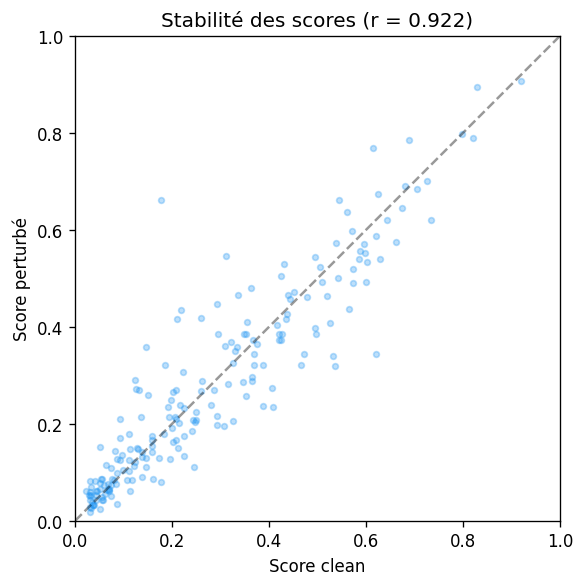

Corrélation scores : 0.922  (1.0 = parfaitement stable)


In [2]:
# ── Perturbation du test set ──────────────────────────────────────────────────
rng_pert = np.random.default_rng(43)  # seed différent du train pour indépendance
perturbed = features.iloc[te].copy()

# Bruit gaussien sur les features numériques
for col in NUMERIC:
    std_train = features.iloc[tr][col].astype(float).std(ddof=1)
    noise = rng_pert.normal(0, 0.2 * std_train, len(perturbed))
    perturbed[col] = perturbed[col].astype(float) + noise

# Remplacement aléatoire des features catégorielles (10%)
for col in CATEG:
    train_vals = features.iloc[tr][col].astype(str).unique()
    if len(train_vals) <= 1:
        continue
    arr = perturbed[col].astype(str).values.copy()
    swap_mask = rng_pert.random(len(arr)) < 0.1
    for i in np.flatnonzero(swap_mask):
        alts = [v for v in train_vals if v != arr[i]]
        if alts:
            arr[i] = rng_pert.choice(alts)
    perturbed[col] = arr

X_te_pert = prep.transform(perturbed)
print(f"Test set perturbé : {X_te_pert.shape}")

# Scores perturbés
scores_te_pert = predict_scores(X_te_pert, w_base, b_base)

# Corrélation scores clean vs perturbés
corr = np.corrcoef(scores_te, scores_te_pert)[0, 1]
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(scores_te, scores_te_pert, alpha=0.3, s=12, c="#2196F3")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("Score clean")
ax.set_ylabel("Score perturbé")
ax.set_title(f"Stabilité des scores (r = {corr:.3f})")
ax.set_aspect("equal")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"Corrélation scores : {corr:.3f}  (1.0 = parfaitement stable)")

---
## 2. Impact sur performance, calibration et fairness

### 2.1 Métriques suivies

- **AUC ROC**: capacité à discriminer défaut/non-défaut
- **ECE**: qualité probabiliste (calibration)
- **|DP|, |EO|** par attribut sensible: dérive d'équité

### 2.2 Règles de lecture des deltas

- `ΔAUC < 0` : perte de discrimination
- `ΔECE > 0` : calibration qui se dégrade
- `Δ|DP| > 0` ou `Δ|EO| > 0` : dérive fairness défavorable

### 2.3 Attention à l'interprétation fairness

Les gaps fairness sont sensibles à:
- la taille des groupes
- le bruit aléatoire injecté
- la convention de classe positive (`Y=1` = défaut)

Donc on lit toujours les deltas **attribut par attribut** (genre vs âge).



In [3]:
# ── Comparaison performances : clean vs perturbé ──────────────────────────────
def ece(y, scores, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1); total = 0.0
    for i in range(n_bins):
        mask = (scores >= bins[i]) & (scores < bins[i+1]) if i < n_bins-1 else (scores >= bins[i])
        if mask.sum() == 0: continue
        total += mask.sum()/len(y) * abs(y[mask].mean() - scores[mask].mean())
    return total

def fairness_gap(y, preds, sens, priv):
    comp = [g for g in np.unique(sens) if g != priv][0]
    sel = lambda g: preds[sens==g].mean()
    tpr = lambda g: ((preds[sens==g]==1)&(y[sens==g]==1)).sum()/max((y[sens==g]==1).sum(),1)
    return abs(sel(comp)-sel(priv)), abs(tpr(comp)-tpr(priv))

preds_pert = (scores_te_pert >= thr_base).astype(int)

print(f"{'Métrique':<25} {'Clean':>10} {'Perturbé':>10} {'Delta':>10}")
print("-" * 60)

auc_c  = auc_roc(y_te, scores_te)
auc_p  = auc_roc(y_te, scores_te_pert)
ece_c  = ece(y_te, scores_te)
ece_p  = ece(y_te, scores_te_pert)

print(f"{'AUC ROC':<25} {auc_c:>10.4f} {auc_p:>10.4f} {auc_p-auc_c:>+10.4f}")
print(f"{'ECE':<25} {ece_c:>10.4f} {ece_p:>10.4f} {ece_p-ece_c:>+10.4f}")

for attr in ["gender", "age"]:
    s_te_attr = sensitive[attr][te]
    dp_c, eo_c = fairness_gap(y_te, preds_base, s_te_attr, PRIVILEGED[attr])
    dp_p, eo_p = fairness_gap(y_te, preds_pert, s_te_attr, PRIVILEGED[attr])
    print(f"{'|DP| ' + attr:<25} {dp_c:>10.4f} {dp_p:>10.4f} {dp_p-dp_c:>+10.4f}")
    print(f"{'|EO| ' + attr:<25} {eo_c:>10.4f} {eo_p:>10.4f} {eo_p-eo_c:>+10.4f}")

Métrique                       Clean   Perturbé      Delta
------------------------------------------------------------
AUC ROC                       0.7932     0.7877    -0.0055
ECE                           0.0575     0.0482    -0.0092
|DP| gender                   0.0942     0.1950    +0.1007
|EO| gender                   0.0438     0.1111    +0.0673
|DP| age                      0.1394     0.1452    +0.0058
|EO| age                      0.0200     0.1000    +0.0800


---
## 3. Calibration avant / après perturbation

Le reliability diagram complète l'ECE:
- diagonale = calibration parfaite
- barres au-dessus de la diagonale = sous-confiance
- barres en dessous = sur-confiance

### Formule ECE

$$ECE = \sum_{b=1}^{B}\frac{|\mathcal{B}_b|}{n}\,|acc(\mathcal{B}_b)-conf(\mathcal{B}_b)|$$

où chaque bin compare fréquence réelle et confiance moyenne.

### Point pratique

Même si l'AUC bouge peu, une hausse d'ECE peut rendre les probabilités
moins exploitables pour des décisions seuilées ou politiques de risque.



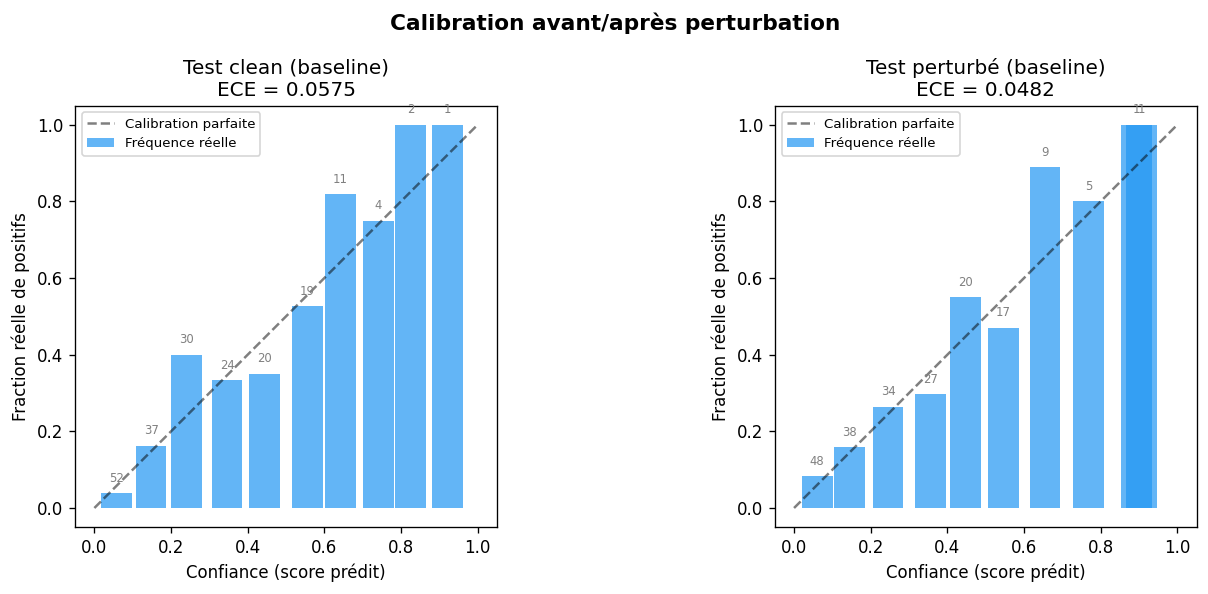

In [4]:
def reliability_diagram(y, scores, title, ax, n_bins=10):
    """Trace le diagramme de calibration (reliability diagram)."""
    bins = np.linspace(0, 1, n_bins+1)
    bin_centers, fracs, confs, counts = [], [], [], []

    for i in range(n_bins):
        if i < n_bins-1:
            mask = (scores >= bins[i]) & (scores < bins[i+1])
        else:
            mask = (scores >= bins[i])
        if mask.sum() == 0:
            continue
        bin_centers.append(scores[mask].mean())
        fracs.append(y[mask].mean())         # fraction réelle de positifs
        confs.append(scores[mask].mean())    # confiance moyenne
        counts.append(mask.sum())

    ece_val = ece(y, scores, n_bins)

    # Barres de calibration
    ax.bar(bin_centers, fracs, width=0.08, alpha=0.7, color="#2196F3",
           label="Fréquence réelle", zorder=2)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Calibration parfaite")
    # Annotations de comptage
    for bc, fc, ct in zip(bin_centers, fracs, counts):
        ax.text(bc, fc + 0.03, str(ct), ha="center", fontsize=7, color="gray")

    ax.set_xlabel("Confiance (score prédit)")
    ax.set_ylabel("Fraction réelle de positifs")
    ax.set_title(f"{title}\nECE = {ece_val:.4f}")
    ax.legend(fontsize=8)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect("equal")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
reliability_diagram(y_te, scores_te,      "Test clean (baseline)",    axes[0])
reliability_diagram(y_te, scores_te_pert, "Test perturbé (baseline)", axes[1])
plt.suptitle("Calibration avant/après perturbation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. Synthèse robustesse

### Ce qu'il faut conclure après exécution

1. Le modèle reste-t-il performant sous bruit réaliste ?
2. Les probabilités restent-elles assez bien calibrées ?
3. Les métriques d'équité dérivent-elles de façon critique ?

### Checklist opérationnelle

- `|ΔAUC|` est-il acceptable pour votre cas d'usage ?
- `ΔECE` reste-t-il dans une zone tolérable ?
- Un attribut sensible montre-t-il une dérive fairness marquée ?

### Actions possibles si dérive excessive

- recalibration périodique (Platt/isotonic)
- régularisation ou feature engineering plus robuste
- monitoring continu par groupe sensible en production

### Message clé

La robustesse ne se résume pas à "l'AUC ne bouge pas".
Il faut suivre **ensemble** performance, calibration et fairness pour garantir
un modèle de crédit réellement fiable en conditions réelles.

